# TITLE

* Description of notebook analysis


#### Goal: Extract election data from PDF table

* File: `../data/general_election.pdf`

* Six pages of tables

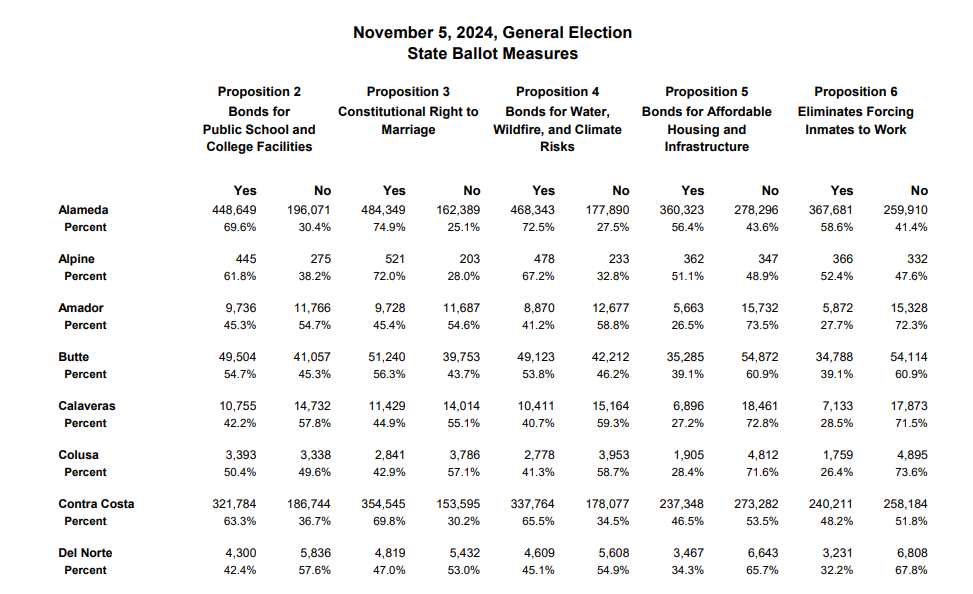{width=400}

* Columns are propositions with data in two subcolumns for YES/NO votes

* Each county has two lines in table
  1. raw number of votes
  2. percentage

* Three pages of data for all counties and two sets of propositions
    1. Props 2,3,4,5 & 6
    2. Props 32,33,34,35 & 36

##### Steps

* For each page:
  1. Get headings for each proposition
  2. Get data frame of raw votes and convert to numeric values
  3. Drop percentages rows (these can be calculated from votes)
* Combine all data frames


### Setup

In [30]:
import camelot
import tabula
import pdfplumber
import pandas as pd

In [3]:
pdf_path = '../data/general_election.pdf'

#### Using `tabula`

* Can try different PDF extraction libraries, starting with `tabula`

In [4]:
tables = tabula.read_pdf(pdf_path, pages='all')

len(tables)

12

* Extracts 12 tables
  - In pairs, first the data table and then column headings, e.g.

In [15]:
tables[0].head()

,Unnamed: 0,Yes,No,Yes.1,No.1,Yes.2,No.2,Yes.3,No.3,Yes.4,No.4
0,Alameda,"448,649","196,071","484,349","162,389","468,343","177,890","360,323","278,296","367,681","259,910"
1,Percent,69.6%,30.4%,74.9%,25.1%,72.5%,27.5%,56.4%,43.6%,58.6%,41.4%
2,Alpine,445,275,521,203,478,233,362,347,366,332
3,Percent,61.8%,38.2%,72.0%,28.0%,67.2%,32.8%,51.1%,48.9%,52.4%,47.6%
4,Amador,"9,736","11,766","9,728","11,687","8,870","12,677","5,663","15,732","5,872","15,328"


In [16]:
tables[1]

,Proposition 2,Proposition 3,Proposition 4,Proposition 5,Proposition 6
0,Bonds for,Constitutional Right to,"Bonds for Water,",Bonds for Affordable,Eliminates Forcing
1,Public School and,Marriage,"Wildfire, and Climate",Housing and,Inmates to Work
2,College Facilities,NaN,Risks,Infrastructure,NaN


* First set of propositions in `tables[0]` to `tables[5]`
* Second set in `tables[6]` to `tables[11]`


#### Create function to carry out the processing steps

1. Get the proposition numbers and descriptions from the column head table (i.e. the first odd numbered in `tables`) and create a dictionary mapping prop number to description (this will be useful for data analysis)

2. Process the data tables
   - These are the even indexes
   - Data are in `str` types with a comma so need to be converted to numeric
   - Three separate tables need to be merged

In [100]:
def extract_data(tables):

    metadata = tables[1]
    
    # 1. get prop numbers and names from first metadata table
    prop_nums = [cname.split()[-1] for cname in metadata.columns]
    prop_descriptions = [' '.join(metadata[col].dropna().values) for col in metadata.columns]
    prop_dict = dict(zip(prop_nums, prop_descriptions))

    # 2. create column names, e.g. ['prop2_yes', 'prop2_no', ...]
    colnames = [f'prop{num}_{vote}' for num in prop_nums for vote in ['yes','no']]
    
    # 3. get data from the three county tables
    data = []
    for dtable in tables[0::2]:
        # get vote data (even rows)
        df = dtable.loc[dtable.index[::2]]

        # rename columns
        df.columns = ['county'] + colnames
        
        # convert to numeric
        df = df.set_index('county').replace(to_replace=',',value='', regex=True).astype(int)

        data.append(df)

    data_df = pd.concat(data)
    data_df = data_df.reset_index()
    return prop_dict, data_df

In [94]:
df1 = pd.DataFrame({'A': [1,2,3], 'x': [1,2,3]})
df2 = pd.DataFrame({'A': [1,2,3], 'y': [4,6,9]})

pd.merge(df1,df2)

,A,x,y
0,1,1,4
1,2,2,6
2,3,3,9


In [103]:
# first set of propositions
prop_dict, prop_df = extract_data(tables[:6])

# second set
# first set of propositions
prop_dict2, prop_df2 = extract_data(tables[6:])

# combine

prop_dict.update(prop_dict2)

combined_df = pd.merge(prop_df, prop_df2)

In [104]:
prop_dict

{'2': 'Bonds for Public School and College Facilities',
 '3': 'Constitutional Right to Marriage',
 '4': 'Bonds for Water, Wildfire, and Climate Risks',
 '5': 'Bonds for Affordable Housing and Infrastructure',
 '6': 'Eliminates Forcing Inmates to Work',
 '32': 'Raises Minimum Wage',
 '33': 'Local Government Residential Rent Control',
 '34': 'Restricts Spending of Prescription Revenues',
 '35': 'Provides Permanent Funding for Medi-Cal',
 '36': 'Increased Sentencing for Certain Drug and Theft Crimes'}

#### Save cleaned data to a CSV file

In [105]:
combined_df.to_csv('../data/general_election_data.csv', index=False)